# XGBoost Peak Hour Classification

**Approach:**
- 24-class classification (peak hour prediction)
- Target: peak hour for each day (0-23)
- Features: daily aggregate features

**Hyperparameter Tuning:**
- Time-based CV (2020-2024)
- Area-specific best parameters

In [1]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime, timedelta
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import accuracy_score

plt.style.use('seaborn-v0_8-darkgrid')
print("✓ Libraries loaded")

✓ Libraries loaded


## Configuration

In [2]:
# Evaluation years
EVAL_YEARS = list(range(2016, 2025))

# Year-based CV windows
CV_WINDOWS = [
    {'train_years': [2016, 2017, 2018, 2019], 'test_year': 2020},
    {'train_years': [2017, 2018, 2019, 2020], 'test_year': 2021},
    {'train_years': [2018, 2019, 2020, 2021], 'test_year': 2022},
    {'train_years': [2019, 2020, 2021, 2022], 'test_year': 2023},
    {'train_years': [2020, 2021, 2022, 2023], 'test_year': 2024}
]

# Black Friday helper
def get_black_friday(year):
    """Returns the Black Friday date for a given year"""
    nov_first = datetime(year, 11, 1)
    days_until_thursday = (3 - nov_first.weekday()) % 7
    first_thursday = nov_first + timedelta(days=days_until_thursday)
    thanksgiving = first_thursday + timedelta(weeks=3)
    black_friday = thanksgiving + timedelta(days=1)
    return black_friday

print(f"Evaluation years: {EVAL_YEARS}")
print(f"CV windows: {len(CV_WINDOWS)}")

Evaluation years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
CV windows: 5


## Load Data

In [3]:
# Load historical data
print("Loading data...")
df = pd.read_parquet('../dataset/preprocessed/full_year_features.parquet')
df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])

print(f"Data loaded: {len(df):,} rows")
print(f"Date range: {df['datetime_beginning_ept'].min()} to {df['datetime_beginning_ept'].max()}")
print(f"Load areas: {df['load_area'].nunique()}")

Loading data...
Data loaded: 3,376,663 rows
Date range: 2012-01-01 00:00:00 to 2025-11-13 23:00:00
Load areas: 34


## Feature Engineering: Daily-Level Features

In [4]:
def create_daily_features(df):
    """Create daily-level features for peak hour classification"""
    print("Creating daily-level features...")
    
    df['date'] = df['datetime_beginning_ept'].dt.date
    
    lag_year_cols = ['mw_bf_lag_1yr', 'mw_bf_lag_2yr', 'mw_bf_lag_3yr', 'mw_bf_lag_4yr']
    idx_cols = ['mw'] + lag_year_cols
    
    agg_dict = {col: 'idxmax' for col in idx_cols}
    daily_peaks = df.groupby(['date', 'load_area']).agg(agg_dict).reset_index()
    
    # Get peak hour for each date/area
    daily_peaks['peak_hour'] = daily_peaks['mw'].map(
        lambda idx: df.loc[idx, 'hour'] if pd.notna(idx) else np.nan
    )
    
    for col in lag_year_cols:
        idx_col = col                      # ex: 'mw_bf_lag_1yr'
        out_col = col.replace('mw_', 'peak_hour_')  # ex: 'peak_hour_bf_lag_1yr'
        daily_peaks[out_col] = daily_peaks[idx_col].map(
            lambda idx: df.loc[idx, 'hour'] if pd.notna(idx) else np.nan
        )
    
    daily_peaks = daily_peaks.drop(columns=idx_cols)
    
    print(f"  Created {len(daily_peaks):,} daily records")
    
    daily_peaks['datetime'] = pd.to_datetime(daily_peaks['date'])
    
    print(f"  Created {len(daily_peaks):,} daily records")
    
    # Add temporal features
    daily_peaks['day_of_week'] = daily_peaks['datetime'].dt.dayofweek
    daily_peaks['month'] = daily_peaks['datetime'].dt.month
    daily_peaks['day_of_month'] = daily_peaks['datetime'].dt.day
    daily_peaks['year'] = daily_peaks['datetime'].dt.year
    daily_peaks['is_blackfriday'] = 0
    daily_peaks['is_thanksgiving'] = 0
    daily_peaks['days_from_bf'] = 0
    
    for year in daily_peaks['year'].unique():
        bf_date = get_black_friday(year)
        thanksgiving_date = bf_date - timedelta(days=1)
        
        mask = daily_peaks['year'] == year
        daily_peaks.loc[mask, 'is_blackfriday'] = (
            daily_peaks.loc[mask, 'datetime'].dt.date == bf_date.date()
        ).astype(int)
        daily_peaks.loc[mask, 'is_thanksgiving'] = (
            daily_peaks.loc[mask, 'datetime'].dt.date == thanksgiving_date.date()
        ).astype(int)
        daily_peaks.loc[mask, 'days_from_bf'] = (
            daily_peaks.loc[mask, 'datetime'].dt.date - bf_date.date()
        ).apply(lambda x: x.days)
    
    print("  Added temporal features")
    
    # Create lag features (Business Day Aware)
    # Data only updated Mon-Thu (Fri-Sun no new data)
    # - Mon: lag 4+ available (previous Thu)
    # - Tue - Sat: lag 2+ available (Thu is lag 2)
    # - Sun: lag 3+ available (Thu is lag 3)
    
    # Create lookup dictionary for quick access
    daily_lookup = daily_peaks.set_index(['load_area', 'datetime'])['peak_hour'].to_dict()
    
    lag_days = [2, 3, 4, 5, 6, 7, 8, 9]
    
    for lag in lag_days:
        print(f"  Creating lag_{lag}d feature (business day aware)...")
        daily_peaks[f'peak_hour_lag_{lag}d'] = np.nan
        
        for idx, row in daily_peaks.iterrows():
            lag_date = row['datetime'] - timedelta(days=lag)
            key = (row['load_area'], lag_date)
            
            # Only fill if data actually exists (Mon-Thu only)
            if key in daily_lookup:
                daily_peaks.loc[idx, f'peak_hour_lag_{lag}d'] = daily_lookup[key]
    
    print("✓ Daily features created (business day aware)")
    return daily_peaks

daily_df = create_daily_features(df)

print(f"\nFinal dataset: {len(daily_df):,} rows")

Creating daily-level features...
  Created 140,694 daily records
  Created 140,694 daily records
  Added temporal features
  Creating lag_2d feature (business day aware)...
  Creating lag_3d feature (business day aware)...
  Creating lag_4d feature (business day aware)...
  Creating lag_5d feature (business day aware)...
  Creating lag_6d feature (business day aware)...
  Creating lag_7d feature (business day aware)...
  Creating lag_8d feature (business day aware)...
  Creating lag_9d feature (business day aware)...
✓ Daily features created (business day aware)

Final dataset: 140,694 rows


In [5]:
daily_df.head()

,date,load_area,peak_hour,peak_hour_bf_lag_1yr,peak_hour_bf_lag_2yr,peak_hour_bf_lag_3yr,peak_hour_bf_lag_4yr,datetime,day_of_week,month,...,is_thanksgiving,days_from_bf,peak_hour_lag_2d,peak_hour_lag_3d,peak_hour_lag_4d,peak_hour_lag_5d,peak_hour_lag_6d,peak_hour_lag_7d,peak_hour_lag_8d,peak_hour_lag_9d
0,2012-01-01,AE,18,NaN,NaN,NaN,NaN,2012-01-01,6,1,...,0,-327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-01,AEP,19,NaN,NaN,NaN,NaN,2012-01-01,6,1,...,0,-327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-01-01,AP,18,NaN,NaN,NaN,NaN,2012-01-01,6,1,...,0,-327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-01-01,BC,18,NaN,NaN,NaN,NaN,2012-01-01,6,1,...,0,-327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-01-01,CE,19,NaN,NaN,NaN,NaN,2012-01-01,6,1,...,0,-327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Prepare Training Data

In [6]:
# Define features
FEATURES = [
    'day_of_week', 'month', 'day_of_month',
    'is_blackfriday', 'is_thanksgiving', 'days_from_bf',
    'peak_hour_lag_2d', 'peak_hour_lag_3d', 'peak_hour_lag_4d', 'peak_hour_lag_5d', 
    'peak_hour_lag_6d', 'peak_hour_lag_7d', 'peak_hour_lag_8d', 'peak_hour_lag_9d',
    'peak_hour_bf_lag_1yr', 'peak_hour_bf_lag_2yr', 'peak_hour_bf_lag_3yr', 'peak_hour_bf_lag_4yr'
]

TARGET = 'peak_hour'

# Filter and prepare
train_df = daily_df.dropna(subset=[TARGET]).copy()

print(f"Training data: {len(train_df):,} rows")

# Check missing values
missing_counts = train_df[FEATURES].isnull().sum()
if missing_counts.sum() > 0:
    print("\nMissing values:")
    for feat, count in missing_counts[missing_counts > 0].items():
        pct = count / len(train_df) * 100
        print(f"  {feat}: {count} ({pct:.1f}%)")
    
    # Fill ALL missing values with -999 (indicator value)
    for feat in FEATURES:
        if train_df[feat].isnull().any():
            train_df[feat] = train_df[feat].fillna(-999)
    
    print("\n✓ Filled ALL missing values with -999 (indicator value)")
else:
    print("\n✓ No missing values")

# Day-of-week based masking (causal simulation)
print("\nApplying day-of-week masking...")
mask_count = 0
for idx, row in train_df.iterrows():
    dow = row['day_of_week']  # 0=Mon, 1=Tue, ..., 6=Sun
    
    if dow == 0:  # Monday: lag 4+ available (mask lag 2,3)
        for lag in [2, 3]:
            train_df.loc[idx, f'actual_peak_load_lag{lag}d'] = -999
            mask_count += 1
    elif dow == 6:  # Sunday: lag 3+ available (mask lag 2)
        for lag in [2]:
            train_df.loc[idx, f'actual_peak_load_lag{lag}d'] = -999
            mask_count += 1

print(f"✓ Day-of-week masking applied ({mask_count} values masked)")

train_df[TARGET] = train_df[TARGET].astype(int)

print(f"\n✓ Training data prepared")

Training data: 140,694 rows

Missing values:
  peak_hour_lag_2d: 98 (0.1%)
  peak_hour_lag_3d: 132 (0.1%)
  peak_hour_lag_4d: 166 (0.1%)
  peak_hour_lag_5d: 200 (0.1%)
  peak_hour_lag_6d: 234 (0.2%)
  peak_hour_lag_7d: 268 (0.2%)
  peak_hour_lag_8d: 302 (0.2%)
  peak_hour_lag_9d: 336 (0.2%)
  peak_hour_bf_lag_1yr: 55544 (39.5%)
  peak_hour_bf_lag_2yr: 66638 (47.4%)
  peak_hour_bf_lag_3yr: 77497 (55.1%)
  peak_hour_bf_lag_4yr: 88214 (62.7%)

✓ Filled ALL missing values with -999 (indicator value)

Applying day-of-week masking...
✓ Day-of-week masking applied (60331 values masked)

✓ Training data prepared


## Load Areas

In [7]:
# Get load areas (exclude RTO and AE)
load_areas = sorted([a for a in train_df['load_area'].unique() if a not in ['RTO', 'AE']])

print(f"Load areas: {len(load_areas)}")
print(f"Areas: {load_areas}")

Load areas: 32
Areas: ['AECO', 'AEP', 'AEPAPT', 'AEPIMP', 'AEPKPT', 'AEPOPT', 'AP', 'BC', 'CE', 'DAY', 'DEOK', 'DOM', 'DPL', 'DPLCO', 'DUQ', 'EASTON', 'EKPC', 'JC', 'ME', 'OE', 'OVEC', 'PAPWR', 'PE', 'PEP', 'PEPCO', 'PLCO', 'PN', 'PS', 'RECO', 'SMECO', 'UGI', 'VMEU']


## Hyperparameter Grid

In [8]:
# Define hyperparameter grid with regularization
# Focus on preventing overfitting
PARAM_GRID = [
    # Shallow trees with regularization
    {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.1, 
     'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0},
    
    {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05, 
     'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0},
    
    # Moderate depth with strong regularization
    {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1, 
     'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 1.0},
    
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 
     'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 1.0},
    
    # Lower learning rate with more trees
    {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.03, 
     'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.3, 'reg_lambda': 1.5},
    
    # Strong regularization (L1 + L2)
    {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05, 
     'min_child_weight': 7, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 1.0, 'reg_lambda': 2.0},
    
    # More aggressive subsampling
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 
     'min_child_weight': 5, 'subsample': 0.6, 'colsample_bytree': 0.6, 'reg_alpha': 0.5, 'reg_lambda': 1.5},
    
    # Conservative: very shallow + strong reg
    {'n_estimators': 50, 'max_depth': 1, 'learning_rate': 0.1, 
     'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.5, 'reg_lambda': 1.0},
    
    # Balanced approach
    {'n_estimators': 75, 'max_depth': 2, 'learning_rate': 0.07, 
     'min_child_weight': 4, 'subsample': 0.75, 'colsample_bytree': 0.75, 'reg_alpha': 0.3, 'reg_lambda': 1.2},
    
    # High min_child_weight (require more samples per leaf)
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 
     'min_child_weight': 10, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 1.5},
    
    # Moderate regularization with more trees
    {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.03, 
     'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0},
    
    # Deeper trees but heavily regularized
    {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 
     'min_child_weight': 7, 'subsample': 0.6, 'colsample_bytree': 0.6, 'reg_alpha': 1.0, 'reg_lambda': 2.0},
]

print(f"Total hyperparameter combinations: {len(PARAM_GRID)}")
print(f"\nRegularization strategies:")
print(f"  - Shallow trees: max_depth 1-4")
print(f"  - min_child_weight: 3-10 (prevent small leaf nodes)")
print(f"  - Subsampling: 0.6-0.8 (row/column sampling)")
print(f"  - L1/L2 regularization: reg_alpha, reg_lambda")
print(f"  - Lower learning rates: 0.03-0.1")

# Ensure all classes (0-23) are always present
ALL_CLASSES = np.arange(24)

Total hyperparameter combinations: 12

Regularization strategies:
  - Shallow trees: max_depth 1-4
  - min_child_weight: 3-10 (prevent small leaf nodes)
  - Subsampling: 0.6-0.8 (row/column sampling)
  - L1/L2 regularization: reg_alpha, reg_lambda
  - Lower learning rates: 0.03-0.1


## Hyperparameter Tuning (Area-Specific)

In [9]:
# Store CV results: area -> param_idx -> cv_scores
area_param_cv_results = {area: [] for area in load_areas}

print("="*80)
print("HYPERPARAMETER OPTIMIZATION (Area-Specific)")
print("="*80)

for param_idx, params in enumerate(PARAM_GRID, 1):
    print(f"\n{'='*80}")
    print(f"Parameter Set {param_idx}/{len(PARAM_GRID)}")
    print(f"  n_est={params['n_estimators']}, depth={params['max_depth']}, "
          f"lr={params['learning_rate']:.3f}")
    print(f"  min_child_wt={params['min_child_weight']}, subsample={params['subsample']}, "
          f"colsample={params['colsample_bytree']}")
    print(f"  reg_alpha={params['reg_alpha']}, reg_lambda={params['reg_lambda']}")
    print(f"{'='*80}")
    
    # For each area, do CV with this param set
    for area_idx, area in enumerate(load_areas, 1):
        # Get area data
        area_data = train_df[train_df['load_area'] == area].copy()
        
        # CV scores for this area & param set
        cv_scores = []
        
        for fold_idx, cv_window in enumerate(CV_WINDOWS, 1):
            train_years = cv_window['train_years']
            test_year = cv_window['test_year']
            
            # Split by CV window
            train_mask = area_data['year'].isin(train_years)
            test_mask = (area_data['year'] == test_year) & (area_data['days_from_bf'] >= -8) & (area_data['days_from_bf'] <= 1)
            
            X_train = area_data.loc[train_mask, FEATURES]
            y_train = area_data.loc[train_mask, TARGET]
            X_test = area_data.loc[test_mask, FEATURES]
            y_test = area_data.loc[test_mask, TARGET]
            
            if len(X_test) == 0:
                continue
            
            # Ensure all classes (0-23)
            missing_classes = set(ALL_CLASSES) - set(y_train.unique())
            
            if missing_classes:
                dummy_X = pd.DataFrame(
                    np.zeros((len(missing_classes), len(FEATURES))),
                    columns=FEATURES
                )
                dummy_y = pd.Series(list(missing_classes))
                
                X_train = pd.concat([X_train, dummy_X], ignore_index=True)
                y_train = pd.concat([y_train, dummy_y], ignore_index=True)
                
                sample_weights = np.ones(len(y_train))
                sample_weights[-len(missing_classes):] = 0
            else:
                sample_weights = None
            
            # Train XGBoost with all regularization parameters
            model = xgb.XGBClassifier(
                n_estimators=params['n_estimators'],
                max_depth=params['max_depth'],
                learning_rate=params['learning_rate'],
                min_child_weight=params['min_child_weight'],
                subsample=params['subsample'],
                colsample_bytree=params['colsample_bytree'],
                reg_alpha=params['reg_alpha'],
                reg_lambda=params['reg_lambda'],
                objective='multi:softmax',
                num_class=24,
                random_state=42,
                n_jobs=-1,
                verbosity=0
            )
            
            model.fit(X_train, y_train, sample_weight=sample_weights, verbose=False)
            
            # Evaluate
            test_pred = model.predict(X_test)
            exact_acc = accuracy_score(y_test, test_pred)
            diff = np.abs(y_test.values - test_pred)
            within_1h_acc = (diff <= 1).mean()
            
            cv_scores.append({
                'fold': fold_idx,
                'test_year': test_year,
                'exact_acc': exact_acc,
                'within_1h_acc': within_1h_acc
            })
        
        # Average CV score for this area & param set
        if cv_scores:
            avg_within_1h = np.mean([s['within_1h_acc'] for s in cv_scores])
            std_within_1h = np.std([s['within_1h_acc'] for s in cv_scores])
            
            area_param_cv_results[area].append({
                'param_idx': param_idx,
                'params': params,
                'cv_within_1h_mean': avg_within_1h,
                'cv_within_1h_std': std_within_1h,
                'cv_scores': cv_scores
            })
    
    print(f"  Completed parameter set {param_idx}")

print(f"\n{'='*80}")
print(f"CV COMPLETE")
print(f"{'='*80}")

HYPERPARAMETER OPTIMIZATION (Area-Specific)

Parameter Set 1/12
  n_est=50, depth=2, lr=0.100
  min_child_wt=3, subsample=0.8, colsample=0.8
  reg_alpha=0.1, reg_lambda=1.0
  Completed parameter set 1

Parameter Set 2/12
  n_est=100, depth=2, lr=0.050
  min_child_wt=3, subsample=0.8, colsample=0.8
  reg_alpha=0.1, reg_lambda=1.0
  Completed parameter set 2

Parameter Set 3/12
  n_est=50, depth=3, lr=0.100
  min_child_wt=5, subsample=0.7, colsample=0.7
  reg_alpha=0.5, reg_lambda=1.0
  Completed parameter set 3

Parameter Set 4/12
  n_est=100, depth=3, lr=0.050
  min_child_wt=5, subsample=0.7, colsample=0.7
  reg_alpha=0.5, reg_lambda=1.0
  Completed parameter set 4

Parameter Set 5/12
  n_est=150, depth=2, lr=0.030
  min_child_wt=5, subsample=0.8, colsample=0.8
  reg_alpha=0.3, reg_lambda=1.5
  Completed parameter set 5

Parameter Set 6/12
  n_est=100, depth=2, lr=0.050
  min_child_wt=7, subsample=0.7, colsample=0.7
  reg_alpha=1.0, reg_lambda=2.0
  Completed parameter set 6

Parameter

## Best Hyperparameters

In [10]:
best_rows = []

for area, param_list in area_param_cv_results.items():
    if not param_list:
        continue
    
    best = max(param_list, key=lambda d: d['cv_within_1h_mean'])
    p = best['params']
    
    best_rows.append({
        'load_area': area,
        'best_param_idx': best['param_idx'],
        'n_estimators': p['n_estimators'],
        'max_depth': p['max_depth'],
        'learning_rate': p['learning_rate'],
        'min_child_weight': p['min_child_weight'],
        'subsample': p['subsample'],
        'colsample_bytree': p['colsample_bytree'],
        'reg_alpha': p['reg_alpha'],
        'reg_lambda': p['reg_lambda'],
        'cv_within_1h_mean': best['cv_within_1h_mean'],
        'cv_within_1h_std': best['cv_within_1h_std'],
        # validation error = 1 - within_1h_acc
        'val_error_mean': 1 - best['cv_within_1h_mean']
    })

best_params_df = pd.DataFrame(best_rows).sort_values('load_area')

print("="*80)
print("BEST HYPERPARAMETERS PER AREA")
print("="*80)
# Show key columns only (too many to display all)
display_cols = ['load_area', 'best_param_idx', 'n_estimators', 'max_depth', 
                'learning_rate', 'min_child_weight', 'cv_within_1h_mean']
print(best_params_df[display_cols].to_string(index=False))

print(f"\n{'='*80}")
print("SUMMARY STATISTICS")
print(f"{'='*80}")
print(f"Average within-1h accuracy: {best_params_df['cv_within_1h_mean'].mean():.2%}")
print(f"Min accuracy: {best_params_df['cv_within_1h_mean'].min():.2%} ({best_params_df.loc[best_params_df['cv_within_1h_mean'].idxmin(), 'load_area']})")
print(f"Max accuracy: {best_params_df['cv_within_1h_mean'].max():.2%} ({best_params_df.loc[best_params_df['cv_within_1h_mean'].idxmax(), 'load_area']})")
print(f"\nRegularization preferences:")
print(f"  Average max_depth: {best_params_df['max_depth'].mean():.1f}")
print(f"  Average min_child_weight: {best_params_df['min_child_weight'].mean():.1f}")
print(f"  Average reg_alpha: {best_params_df['reg_alpha'].mean():.2f}")
print(f"  Average reg_lambda: {best_params_df['reg_lambda'].mean():.2f}")

BEST HYPERPARAMETERS PER AREA
load_area  best_param_idx  n_estimators  max_depth  learning_rate  min_child_weight  cv_within_1h_mean
     AECO               1            50          2           0.10                 3               0.98
   AEPAPT               6           100          2           0.05                 7               0.66
   AEPIMP               3            50          3           0.10                 5               0.44
   AEPKPT               7           100          3           0.05                 5               0.64
   AEPOPT              12           100          4           0.05                 7               0.50
       AP              12           100          4           0.05                 7               0.50
       BC               8            50          1           0.10                 5               0.62
       CE               1            50          2           0.10                 3               0.92
      DAY               3            50    

In [11]:
best_params_df['cv_within_1h_mean'].mean()

np.float64(0.6593103448275862)

## Save Models for Production

Save trained XGBosst models for each area

In [12]:
import os
import pickle
import numpy as np
import pandas as pd
import xgboost as xgb

models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

print("="*80)
print("SAVING XGBOOST MODELS (AREA-SPECIFIC)")
print("="*80)

xgb_models = {}

for idx, row in best_params_df.iterrows():
    area = row['load_area']
    
    # Select area-specific data
    area_data = train_df[train_df['load_area'] == area].copy()
    X_all = area_data[FEATURES]
    y_all = area_data[TARGET]

    # Remove rows with missing values
    valid_mask = X_all.notna().all(axis=1) & y_all.notna()
    X_clean = X_all.loc[valid_mask].reset_index(drop=True)
    y_clean = y_all.loc[valid_mask].reset_index(drop=True)

    if len(X_clean) == 0:
        print(f"  ! {area:10s} -> no valid data, skipped")
        continue

    # Add dummy samples for missing classes (ensure num_class = 24)
    missing_classes = set(range(24)) - set(y_clean.unique())

    if missing_classes:
        dummy_X = pd.DataFrame(
            np.zeros((len(missing_classes), len(FEATURES))),
            columns=FEATURES
        )
        dummy_y = pd.Series(list(missing_classes), name=TARGET)

        X_final = pd.concat([X_clean, dummy_X], ignore_index=True)
        y_final = pd.concat([y_clean, dummy_y], ignore_index=True)

        sample_weights = np.ones(len(y_final))
        sample_weights[-len(missing_classes):] = 0
    else:
        X_final = X_clean
        y_final = y_clean
        sample_weights = None

    # Train XGBClassifier with optimal hyperparameters (including regularization)
    model = xgb.XGBClassifier(
        n_estimators=int(row['n_estimators']),
        max_depth=int(row['max_depth']),
        learning_rate=float(row['learning_rate']),
        min_child_weight=int(row['min_child_weight']),
        subsample=float(row['subsample']),
        colsample_bytree=float(row['colsample_bytree']),
        reg_alpha=float(row['reg_alpha']),
        reg_lambda=float(row['reg_lambda']),
        objective='multi:softmax',
        num_class=24,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    model.fit(X_final, y_final, sample_weight=sample_weights, verbose=False)

    # Save model
    model_path = f"{models_dir}/xgb_{area}.pkl"
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)

    xgb_models[area] = model
    print(f"  ✓ {area:10s} -> {model_path}")

# Save model metadata
metadata = {
    'features': FEATURES,
    'load_areas': best_params_df['load_area'].tolist(),
    'model_type': 'XGBClassifier',
    'num_classes': 24,
    'horizon_hours': 24,
    'best_params_df': best_params_df.to_dict(orient='list'),
    'regularization': 'enabled'
}

metadata_path = f"{models_dir}/xgb_model_metadata.pkl"
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)

print(f"\n✓ Metadata saved to: {metadata_path}")
print("="*80)
print("✓ All XGBoost models saved successfully")
print("="*80)


SAVING XGBOOST MODELS (AREA-SPECIFIC)
  ✓ AECO       -> ../models/xgb_AECO.pkl
  ✓ AEPAPT     -> ../models/xgb_AEPAPT.pkl
  ✓ AEPIMP     -> ../models/xgb_AEPIMP.pkl
  ✓ AEPKPT     -> ../models/xgb_AEPKPT.pkl
  ✓ AEPOPT     -> ../models/xgb_AEPOPT.pkl
  ✓ AP         -> ../models/xgb_AP.pkl
  ✓ BC         -> ../models/xgb_BC.pkl
  ✓ CE         -> ../models/xgb_CE.pkl
  ✓ DAY        -> ../models/xgb_DAY.pkl
  ✓ DEOK       -> ../models/xgb_DEOK.pkl
  ✓ DOM        -> ../models/xgb_DOM.pkl
  ✓ DPLCO      -> ../models/xgb_DPLCO.pkl
  ✓ DUQ        -> ../models/xgb_DUQ.pkl
  ✓ EASTON     -> ../models/xgb_EASTON.pkl
  ✓ EKPC       -> ../models/xgb_EKPC.pkl
  ✓ JC         -> ../models/xgb_JC.pkl
  ✓ ME         -> ../models/xgb_ME.pkl
  ✓ OE         -> ../models/xgb_OE.pkl
  ✓ OVEC       -> ../models/xgb_OVEC.pkl
  ✓ PAPWR      -> ../models/xgb_PAPWR.pkl
  ✓ PE         -> ../models/xgb_PE.pkl
  ✓ PEPCO      -> ../models/xgb_PEPCO.pkl
  ✓ PLCO       -> ../models/xgb_PLCO.pkl
  ✓ PN         -> ../mo

## Feature Importance

In [13]:
import pandas as pd

fi_rows = []

print("="*80)
print("COMPUTING FEATURE IMPORTANCE (XGBOOST)")
print("="*80)

for area in best_params_df['load_area']:
    # Load model from memory; if missing, load from disk
    model = xgb_models.get(area)
    if model is None:
        model_path = f"{models_dir}/xgb_{area}.pkl"
        if not os.path.exists(model_path):
            print(f"  ! {area:10s} -> model not found, skipped")
            continue
        with open(model_path, 'rb') as f:
            model = pickle.load(f)

    # Extract feature importance
    importances = model.feature_importances_

    for feat, imp in zip(FEATURES, importances):
        fi_rows.append({
            'load_area': area,
            'feature': feat,
            'importance': float(imp)
        })

    print(f"  ✓ {area:10s} -> feature importance collected")

feature_importance_df = pd.DataFrame(fi_rows)

# Normalize importance within each area (optional)
feature_importance_df['importance_norm'] = (
    feature_importance_df.groupby('load_area')['importance']
    .transform(lambda x: x / x.sum() if x.sum() > 0 else x)
)

# Save outputs
fi_csv = f"{models_dir}/xgb_feature_importance.csv"
feature_importance_df.to_csv(fi_csv, index=False)

fi_pkl = f"{models_dir}/xgb_feature_importance.pkl"
with open(fi_pkl, 'wb') as f:
    pickle.dump(feature_importance_df, f)

print(f"\n✓ Feature importance saved to: {fi_csv}")
print(f"✓ Pickle saved to: {fi_pkl}")
print("="*80)
print("✓ Feature importance calculation complete")
print("="*80)


COMPUTING FEATURE IMPORTANCE (XGBOOST)
  ✓ AECO       -> feature importance collected
  ✓ AEPAPT     -> feature importance collected
  ✓ AEPIMP     -> feature importance collected
  ✓ AEPKPT     -> feature importance collected
  ✓ AEPOPT     -> feature importance collected
  ✓ AP         -> feature importance collected
  ✓ BC         -> feature importance collected
  ✓ CE         -> feature importance collected
  ✓ DAY        -> feature importance collected
  ✓ DEOK       -> feature importance collected
  ✓ DOM        -> feature importance collected
  ✓ DPLCO      -> feature importance collected
  ✓ DUQ        -> feature importance collected
  ✓ EASTON     -> feature importance collected
  ✓ EKPC       -> feature importance collected
  ✓ JC         -> feature importance collected
  ✓ ME         -> feature importance collected
  ✓ OE         -> feature importance collected
  ✓ OVEC       -> feature importance collected
  ✓ PAPWR      -> feature importance collected
  ✓ PE         -> fea

<Figure size 1000x600 with 0 Axes>

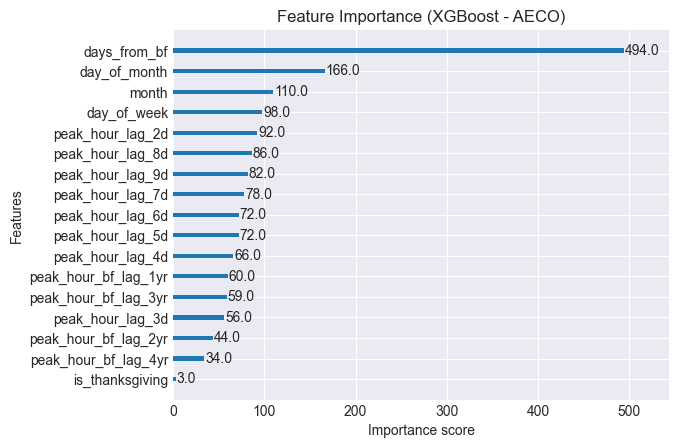

In [14]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

model = xgb_models["AECO"]  

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=20)  # top 20
plt.title("Feature Importance (XGBoost - AECO)")
plt.show()


## Peak Hour Evaluation

**Objective:**
- Evaluate peak hour prediction accuracy
- Period: BF-9 to Black Friday (2016-2024)
- Criteria: Within ±1 hour = correct

In [15]:
# Predict peak hours for all years and days
results = []

for year in EVAL_YEARS:
    bf_date = get_black_friday(year)
    
    print(f"\n{'='*80}")
    print(f"Year {year}: Black Friday = {bf_date.strftime('%Y-%m-%d')}")
    print(f"{'='*80}")
    
    # Evaluate BF-9 to BF
    for days_before in range(9, -1, -1):
        target_date = bf_date - timedelta(days=days_before)
        
        # Get data for this date
        date_data = daily_df[daily_df['datetime'].dt.date == target_date.date()].copy()
        
        if len(date_data) == 0:
            print(f"  {target_date.strftime('%Y-%m-%d')}: No data")
            continue
        
        print(f"  {target_date.strftime('%Y-%m-%d')} (BF-{days_before}): ", end="")
        
        # For each area
        for area in load_areas:
            area_data = date_data[date_data['load_area'] == area].copy()
            
            if len(area_data) == 0:
                continue
            
            # Get actual peak hour
            actual_peak_hour = int(area_data['peak_hour'].iloc[0])
            
            # Prepare features for prediction
            X = area_data[FEATURES]
            
            # Fill missing values with -999 (same as training)
            for feat in FEATURES:
                if X[feat].isnull().any():
                    X[feat] = X[feat].fillna(-999)
            
            # Load model for this area
            model = xgb_models.get(area)
            if model is None:
                continue
            
            # Predict
            predicted_peak_hour = int(model.predict(X)[0])
            
            # Calculate difference
            diff = abs(predicted_peak_hour - actual_peak_hour)
            is_correct = diff <= 1  # Within ±1 hour
            
            # Store result
            results.append({
                'year': year,
                'date': target_date,
                'days_before_bf': days_before,
                'area': area,
                'actual_peak_hour': actual_peak_hour,
                'predicted_peak_hour': predicted_peak_hour,
                'difference': diff,
                'is_correct': is_correct
            })
        
        print(f"{len([r for r in results if r['date'] == target_date])} areas evaluated")

# Create DataFrame
results_df = pd.DataFrame(results)

print(f"\n{'='*80}")
print(f"✓ Evaluation complete")
print(f"{'='*80}")
print(f"Total predictions: {len(results_df)}")
print(f"Years: {results_df['year'].nunique()}")
print(f"Dates: {results_df['date'].nunique()}")
print(f"Areas: {results_df['area'].nunique()}")


Year 2016: Black Friday = 2016-11-25
  2016-11-16 (BF-9): 26 areas evaluated
  2016-11-17 (BF-8): 26 areas evaluated
  2016-11-18 (BF-7): 

/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_16062/2372930961.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[feat] = X[feat].fillna(-999)
/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_16062/2372930961.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[feat] = X[feat].fillna(-999)
/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_16062/2372930961.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

26 areas evaluated
  2016-11-19 (BF-6): 26 areas evaluated
  2016-11-20 (BF-5): 26 areas evaluated


/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_16062/2372930961.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[feat] = X[feat].fillna(-999)
/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_16062/2372930961.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[feat] = X[feat].fillna(-999)
/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_16062/2372930961.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

  2016-11-21 (BF-4): 26 areas evaluated
  2016-11-22 (BF-3): 26 areas evaluated
  2016-11-23 (BF-2): 

...

29 areas evaluated
  2022-11-22 (BF-3): 29 areas evaluated
  2022-11-23 (BF-2): 29 areas evaluated
  2022-11-24 (BF-1): 

/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_16062/2372930961.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[feat] = X[feat].fillna(-999)
/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_16062/2372930961.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[feat] = X[feat].fillna(-999)
/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_16062/2372930961.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

29 areas evaluated
  2022-11-25 (BF-0): 29 areas evaluated

Year 2023: Black Friday = 2023-11-24
  2023-11-15 (BF-9): 29 areas evaluated
  2023-11-16 (BF-8): 

/var/folders/kp/c5r14smx5gj41nmfg_mpskw80000gr/T/ipykernel_16062/2372930961.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[feat] = X[feat].fillna(-999)


29 areas evaluated
  2023-11-17 (BF-7): 29 areas evaluated
  2023-11-18 (BF-6): 29 areas evaluated
  2023-11-19 (BF-5): 29 areas evaluated
  2023-11-20 (BF-4): 29 areas evaluated
  2023-11-21 (BF-3): 29 areas evaluated
  2023-11-22 (BF-2): 29 areas evaluated
  2023-11-23 (BF-1): 29 areas evaluated
  2023-11-24 (BF-0): 29 areas evaluated

Year 2024: Black Friday = 2024-11-29
  2024-11-20 (BF-9): 29 areas evaluated
  2024-11-21 (BF-8): 29 areas evaluated
  2024-11-22 (BF-7): 29 areas evaluated
  2024-11-23 (BF-6): 29 areas evaluated
  2024-11-24 (BF-5): 29 areas evaluated
  2024-11-25 (BF-4): 29 areas evaluated
  2024-11-26 (BF-3): 29 areas evaluated
  2024-11-27 (BF-2): 29 areas evaluated
  2024-11-28 (BF-1): 29 areas evaluated
  2024-11-29 (BF-0): 29 areas evaluated

✓ Evaluation complete
Total predictions: 2560
Years: 9
Dates: 90
Areas: 29


### Save Results

In [16]:
# Accuracy by days before BF
days_accuracy = results_df.groupby('days_before_bf').agg({
    'is_correct': ['mean', 'sum', 'count'],
    'difference': 'mean'
}).round(4)

days_accuracy.columns = ['accuracy', 'correct', 'total', 'avg_diff']
days_accuracy['accuracy'] = days_accuracy['accuracy'] * 100

print(f"{'='*80}")
print(f"ACCURACY BY DAYS BEFORE BLACK FRIDAY")
print(f"{'='*80}")
print(days_accuracy.to_string())

ACCURACY BY DAYS BEFORE BLACK FRIDAY
                accuracy  correct  total  avg_diff
days_before_bf                                    
0                  71.88      184    256    2.7539
1                  32.03       82    256    4.4961
2                  58.59      150    256    3.6875
3                  66.80      171    256    3.2773
4                  68.36      175    256    3.3242
5                  87.11      223    256    1.5664
6                  68.75      176    256    3.0273
7                  66.02      169    256    2.9883
8                  63.67      163    256    3.6875
9                  66.02      169    256    3.4961


### Accuracy by Days Before BF

In [17]:
# Accuracy by area
area_accuracy = results_df.groupby('area').agg({
    'is_correct': ['mean', 'sum', 'count'],
    'difference': 'mean'
}).round(4)

area_accuracy.columns = ['accuracy', 'correct', 'total', 'avg_diff']
area_accuracy['accuracy'] = area_accuracy['accuracy'] * 100
area_accuracy = area_accuracy.sort_values('accuracy', ascending=False)

print(f"{'='*80}")
print(f"ACCURACY BY AREA (Top 10 and Bottom 10)")
print(f"{'='*80}")
print("\nTop 10:")
print(area_accuracy.head(10).to_string())
print("\nBottom 10:")
print(area_accuracy.tail(10).to_string())

ACCURACY BY AREA (Top 10 and Bottom 10)

Top 10:
        accuracy  correct  total  avg_diff
area                                      
RECO       98.89       89     90    0.1333
PS         98.89       89     90    0.1444
JC         96.67       87     90    0.6000
VMEU       96.25       77     80    0.3625
AECO       93.75       75     80    0.5125
CE         92.22       83     90    0.8889
PE         77.78       70     90    2.0222
UGI        68.89       62     90    3.0000
DUQ        67.78       61     90    2.4444
AEPAPT     63.33       57     90    3.7778

Bottom 10:
        accuracy  correct  total  avg_diff
area                                      
AP         55.56       50     90    4.4778
PAPWR      54.44       49     90    3.4111
DEOK       54.44       49     90    4.0000
DPLCO      52.22       47     90    5.1444
SMECO      51.11       46     90    5.5222
PLCO       48.89       44     90    4.5333
DAY        48.89       44     90    4.4111
AEPOPT     47.78       43     90    

### Accuracy by Area

In [18]:
# Accuracy by year
year_accuracy = results_df.groupby('year').agg({
    'is_correct': ['mean', 'sum', 'count'],
    'difference': 'mean'
}).round(4)

year_accuracy.columns = ['accuracy', 'correct', 'total', 'avg_diff']
year_accuracy['accuracy'] = year_accuracy['accuracy'] * 100

print(f"{'='*80}")
print(f"ACCURACY BY YEAR")
print(f"{'='*80}")
print(year_accuracy.to_string())

ACCURACY BY YEAR
      accuracy  correct  total  avg_diff
year                                    
2016     65.38      170    260    3.1577
2017     62.86      176    280    3.7143
2018     69.29      194    280    2.8393
2019     64.48      187    290    3.0897
2020     65.86      191    290    2.9517
2021     64.83      188    290    3.4276
2022     65.17      189    290    3.5345
2023     65.17      189    290    2.9759
2024     61.38      178    290    3.3793


### Accuracy by Year

In [19]:
# Overall accuracy
overall_accuracy = results_df['is_correct'].mean() * 100

print(f"{'='*80}")
print(f"OVERALL PEAK HOUR PREDICTION ACCURACY (XGBOOST)")
print(f"{'='*80}")
print(f"Accuracy (±1 hour): {overall_accuracy:.2f}%")
print(f"Correct predictions: {results_df['is_correct'].sum()}/{len(results_df)}")
print(f"\nDifference distribution:")
print(results_df['difference'].value_counts().sort_index())

# Average difference
avg_diff = results_df['difference'].mean()
print(f"\nAverage difference: {avg_diff:.2f} hours")

OVERALL PEAK HOUR PREDICTION ACCURACY (XGBOOST)
Accuracy (±1 hour): 64.92%
Correct predictions: 1662/2560

Difference distribution:
difference
0     1238
1      424
2       48
3       72
4       32
5       22
6       32
7       57
8       64
9       60
10     198
11     188
12      62
13      43
14      12
15       2
16       1
17       2
18       3
Name: count, dtype: int64

Average difference: 3.23 hours
